In [1]:
# Standard Imports
import numpy as np # standard numerical math lib
import json # Read/write JSON files
import glob, re, os # pattern-based filename matching, regular expressions i.e. parsing strings, OS utitilies i.e. paths, env. variables, directory operations
from tqdm.notebook import tqdm # progress bar for loops
from astroquery.vizier import Vizier # to get DESI cluster data
import pandas as pd # reading csvs
from collections import Counter

# Astronomy
import fitsio # a fast FITS reader (often faster than astropy.io.fits)
from astropy.io import fits # astropy's FITS I/O module (similar to fitsio)
from astropy.table import Table # astropys table class
import healpy as hp # used for full-sky maps
from astropy.cosmology import Planck18 as cosmo # imports Planck 2018 best-fit parameters
import astropy.units as u # Astropy units system
from astropy.coordinates import SkyCoord

# density cube
from numba import njit # python compiler (makes code faster)

# Plotting
import matplotlib.pyplot as plt # iykyk
from skimage.measure import marching_cubes # extracts an isosurface mesh from a 3D scalar field (useful for visualizing cosmic web)
from mpl_toolkits.mplot3d.art3d import Poly3DCollection # plotting 3D polygon meshes
from matplotlib.colors import LogNorm # logarithmic normalization for color scales
from matplotlib.animation import FuncAnimation, PillowWriter # animate a figure, export animation as GIF
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from scipy.ndimage import binary_erosion
from matplotlib.lines import Line2D

# Density Identifyer
import pycosmommf as mmf

# VoidFinder Comparison
from sklearn.neighbors import KDTree
import vast.catalog.void_catalog as void_catalog

In [2]:
# make a toy "1+delta" field on a 64^3 grid
N = 64
x = np.linspace(-1, 1, N, endpoint=False)
X, Y, Z = np.meshgrid(x, x, x, indexing="ij") #3D arrays that store the coordinate of each voxel in space
"""Make a 64×64×64 grid with coordinates in [-1,1).
Note: voxel (volume element) is a 3D pixel (picture element) 
So we have 260,000 voxels and each axis coordinate runs from –1 to +1."""

#a sum of three Gaussians, each centered at a different location, with different widths and amplitudes
delta = (
    3.0*np.exp(-((X+0.3)**2+(Y+0.2)**2+(Z-0.1)**2)/0.02) +   # a "clusterish" blob (centered (-0.3, -0.2, +0.1) narrow width (denominator 0.02), amplitude +3.0 (a big overdensity)
    1.5*np.exp(-((X-0.4)**2+(Y-0.4)**2)/0.01) +              # a "filamentish" ridge (depends only on X and Y, not Z. Centered at (+0.4, +0.4) in the XY plane. Narrow in X,Y (denominator 0.01), but infinite extent along Z. Amplitude +1.5. This is like a cylinder through the cube.
    -0.8*np.exp(-((X+0.2)**2+(Y-0.5)**2+(Z+0.3)**2)/0.05)    # a "voidish" dip (Centered at (–0.2, +0.5, –0.3). Broader width (denominator 0.05). Amplitude negative (–0.8).
)

density_field = 1.0 + delta                                  # NEXUS+ expects a positive field (ie: density relative to the mean)

print("delta stats:",
      f"min={delta.min():.3f}", f"max={delta.max():.3f}", f"mean={delta.mean():.3f}")

delta stats: min=-0.795 max=2.948 mean=0.011


The overdensity field is defined as

$$
\delta(\mathbf{x}) = \frac{\rho(\mathbf{x}) - \bar{\rho}}{\bar{\rho}} \, ,
$$
If δ = 0 → the region has exactly the mean density.
If δ = +1 → twice the mean density.
If δ = –0.5 → half the mean density.
If δ < –1 → that would mean negative physical density (unphysical; shouldn’t happen in a realistic δ field, though noise in mocks can give artifacts). \
Which can also be written as

$$
1 + \delta(\mathbf{x}) = \frac{\rho(\mathbf{x})}{\bar{\rho}} \, .
$$

**Where:**
- $\mathbf{x}$ = position in space (the voxel location in our 3D grid)  
- $\rho(\mathbf{x})$ = matter density at that position  
- $\bar{\rho}$ = mean matter density of the whole box / universe  
- $\delta(\mathbf{x})$ = overdensity, i.e. the fractional deviation from the mean

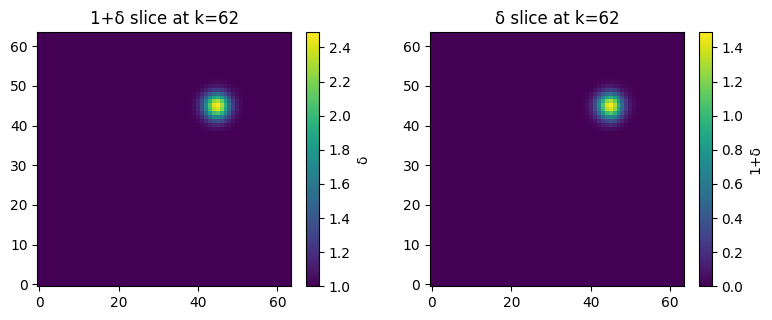

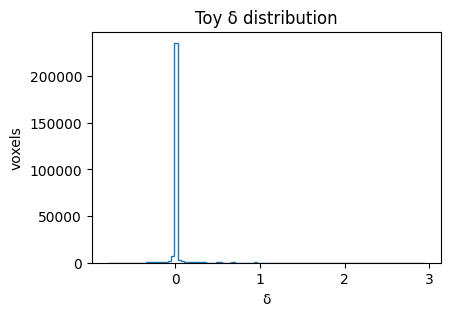

In [3]:
# a mid-plane slice of 1+δ and δ
k = 62
fig, axs = plt.subplots(1,2, figsize=(8,3.3))
im0 = axs[0].imshow(density_field[:,:,k], origin="lower"); axs[0].set_title(f"1+δ slice at k={k}")
cbar0 = fig.colorbar(im0, ax=axs[0], fraction=0.046)
cbar0.set_label("δ")
im1 = axs[1].imshow(delta[:,:,k], origin="lower"); axs[1].set_title(f"δ slice at k={k}")
cbar1 = fig.colorbar(im1, ax=axs[1], fraction=0.046)
cbar1.set_label("1+δ")

plt.tight_layout(); plt.show()

# looking at the distribution of all overdensity voxels in the grid
plt.figure(figsize=(4.5,3))
plt.hist(delta.ravel(), bins=100, histtype="step"); plt.xlabel("δ"); plt.ylabel("voxels") # essentially a probability distribution function of delta. In a realistic cosmological density field, the PDF of δ has a characteristic skew (lots of voids, a few very overdense regions).
plt.title("Toy δ distribution"); plt.show()

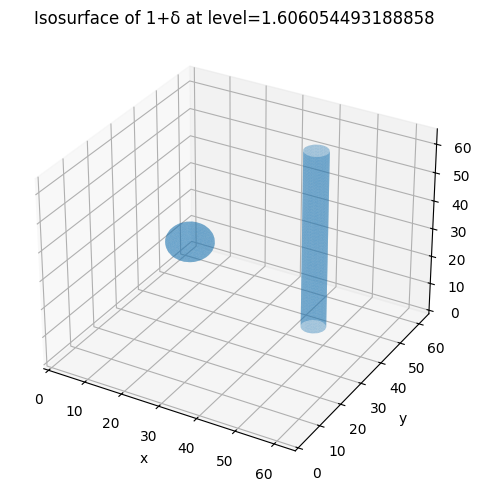

In [4]:
vol = density_field.astype(np.float32)    # 1+δ
level = np.percentile(vol, 99)           # choose an iso-level

verts, faces, normals, values = marching_cubes(vol, level=level)

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')

mesh = Poly3DCollection(verts[faces], alpha=0.4)  # semi-transparent surface
ax.add_collection3d(mesh)

ax.set_xlim(0, vol.shape[0]); ax.set_ylim(0, vol.shape[1]); ax.set_zlim(0, vol.shape[2])
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title(f'Isosurface of 1+δ at level={level}')
plt.tight_layout(); plt.show()

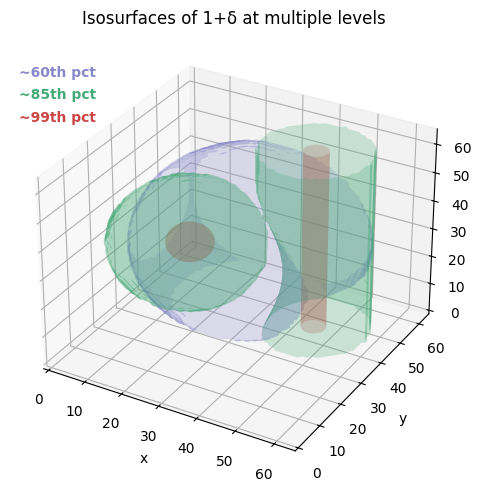

In [5]:
vol = density_field.astype(np.float32)
levels = [np.percentile(vol, p) for p in (25, 60, 99)]  # void/walls-ish → filament → peaks

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')

colors = ['#88c', '#4a7', '#c44']
labels = ['~60th pct', '~85th pct', '~99th pct']

for lev, col, lab in zip(levels, colors, labels):
    v, f, n, vals = marching_cubes(vol, level=lev)
    mesh = Poly3DCollection(v[f], alpha=0.25, facecolor=col, edgecolor='none')
    ax.add_collection3d(mesh)

ax.set_xlim(0, vol.shape[0]); ax.set_ylim(0, vol.shape[1]); ax.set_zlim(0, vol.shape[2])
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Isosurfaces of 1+δ at multiple levels')
# simple legend proxies
for col, lab, y in zip(colors, labels, [0.9, 0.85, 0.80]):
    ax.text2D(0.02, y, lab, transform=ax.transAxes, color=col, fontsize=10, weight='bold')

plt.tight_layout(); plt.show()

In [6]:
# multiscale smoothing radii (in voxels or box units)
Rs = [np.sqrt(2.0)**n for n in range(6)]

In [7]:
# max signatures (0:clusters, 1: filaments, 2:walls)
max_sigs = mmf.maximum_signature(Rs, density_field, algorithm="NEXUSPLUS")

In [8]:
# boolean masks for each webtype
clus, fil, wall, void = mmf.calc_structure_bools(density_field, max_sigs, verbose_flag=False)

/global/homes/j/jlargett/miniforge3/lib/python3.10/site-packages/pycosmommf/tagging.py:68: RuntimeWarning: invalid value encountered in scalar divide
  virialized_fractions[i] = np.sum(


In [9]:
print("Volume fractions:",
      f"cluster={clus.mean():.3f}",
      f"filament={fil.mean():.3f}",
      f"wall={wall.mean():.3f}",
      f"void={void.mean():.3f}")

Volume fractions: cluster=0.000 filament=0.020 wall=0.063 void=0.917


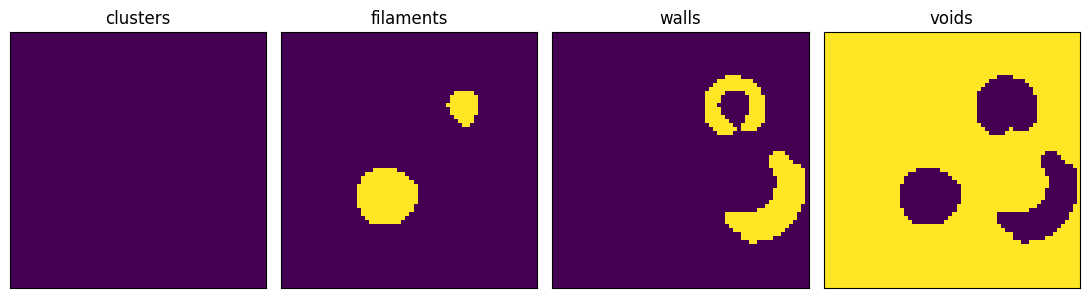

In [10]:
k = 32  # middle slice
fig, axs = plt.subplots(1,4, figsize=(11,3))

axs[0].imshow(clus[:,:,k].astype(int), origin="lower"); axs[0].set_title("clusters")
axs[1].imshow(fil [:,:,k].astype(int), origin="lower"); axs[1].set_title("filaments")
axs[2].imshow(wall[:,:,k].astype(int), origin="lower"); axs[2].set_title("walls")
axs[3].imshow(void[:,:,k].astype(int), origin="lower"); axs[3].set_title("voids")

for a in axs: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

## BGS Data

In [11]:
data_fn = "/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP/BGS_ANY_clustering.dat.fits" #BGS data

# Load the header
tab = Table.read(data_fn, hdu=1)

# Show all column names
print("Columns:", tab.colnames)

Columns: ['TARGETID', 'TILEID', 'Z', 'NTILE', 'RA', 'DEC', 'PHOTSYS', 'FRAC_TLOBS_TILES', 'WEIGHT_ZFAIL', 'BITWEIGHTS', 'PROB_OBS', 'WEIGHT', 'WEIGHT_COMP', 'WEIGHT_SYS', 'flux_g_dered', 'flux_r_dered', 'flux_z_dered', 'flux_w1_dered', 'flux_w2_dered']


In [12]:
base = "/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP" # where the unblinded BGS data lives

In [13]:
# in survey data you don’t have periodic uniform coverage, so estimate the selection function with randoms
cand = glob.glob(f"{base}/BGS_ANY_*_clustering.ran.fits") # path to random files

# synthesize random files
ran_files = []
for fn in cand:
    m = re.search(r"/BGS_ANY_(\d+)_clustering\.ran\.fits$", fn)
    if m:
        ran_files.append(fn)

# sort numerically by the split index
ran_files = sorted(ran_files, key=lambda s: int(re.search(r"_(\d+)_clustering", s).group(1)))

print("N numeric-split random files:", len(ran_files))
print("first/last:", ran_files[0], ran_files[-1])

N numeric-split random files: 18
first/last: /global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP/BGS_ANY_0_clustering.ran.fits /global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP/BGS_ANY_17_clustering.ran.fits


In [14]:
# Build 2D Angular Random Map on the sky (angular selection function)
# Randoms correct spatial selection, with no randoms edges are classified as voids etc. (i.e. where gals were allowed to exist)
NSIDE = 128
npix = hp.nside2npix(NSIDE) # given thus HEALPix resolution (NSIDE), how many total sky pixels are there? N_pix = 12 times NSIDE^2, i.e. 196,608 equal-area pixels

# convert ra and dec to theta and phi since HEALPix expects this
PIX = lambda ra, dec: hp.ang2pix(NSIDE,
                                 np.deg2rad(90 - dec),
                                 np.deg2rad(ra))

n_rand = np.zeros(npix, dtype=np.float64) # initialize n_rand

# loop over random files
for fn in ran_files:
    arr_r = fitsio.read(fn, columns=["RA","DEC", "Z"], ext=1) # read each random catalog
    n_rand += np.bincount(PIX(arr_r["RA"], arr_r["DEC"]), minlength=npix) # convert each object to a HEALPix pixel and count how many land in each pixel
n_rand = n_rand.astype(np.float32) # gives total number of random objects in HEALPix pixel

In [15]:
# 2D angular weighted map of BGS
# Weights correct gal amplitudes, without weights you will get artifical overdensities in regions of low completeness (i.e. how much each gal counts)
arr_d = fitsio.read(data_fn, columns=["RA","DEC","Z","WEIGHT","PHOTSYS"], ext=1) # read in gal positions and weights
pix_d = PIX(arr_d["RA"], arr_d["DEC"]) # convert each gal to a HEALPix pixel
n_data = np.bincount(pix_d, weights=arr_d["WEIGHT"], minlength=npix).astype(np.float32) # weighted galaxy count per sky pixel

In [16]:
mask = n_rand > 0 # select only where there are randoms (only consider galaxies inside footprint)

# Random catalog is much denser than the real data, so rescale by alpha so that the random catalog becomes a proper estimator of the mean density, ensuring that the overdensity field has zero mean and represents real clustering rather than arbitrary normalization
alpha = n_data[mask].sum() / n_rand[mask].sum() # weighted gal count / random count

# computing angular overdensity
delta_ang = np.full(npix, hp.UNSEEN, dtype=np.float32) # initialize every pixel
delta_ang[mask] = n_data[mask] / (alpha * n_rand[mask]) - 1.0 # positive = overdense, negative = underdense

In [17]:
print("mean delta:", float(delta_ang[mask].mean())) # mean angular density
print("min/max delta:", float(delta_ang[mask].min()), float(delta_ang[mask].max())) # smallest and largest values
print("mask sky frac:", mask.mean()) # what fractions of the full sky the survey footprint covers (DESI footprint is roughly 14,000 deg^2 out of 41,253 deg^2 full sky ~ 0.34)

mean delta: 0.0024820338003337383
min/max delta: -1.0 198.835693359375
mask sky frac: 0.3495839436848958


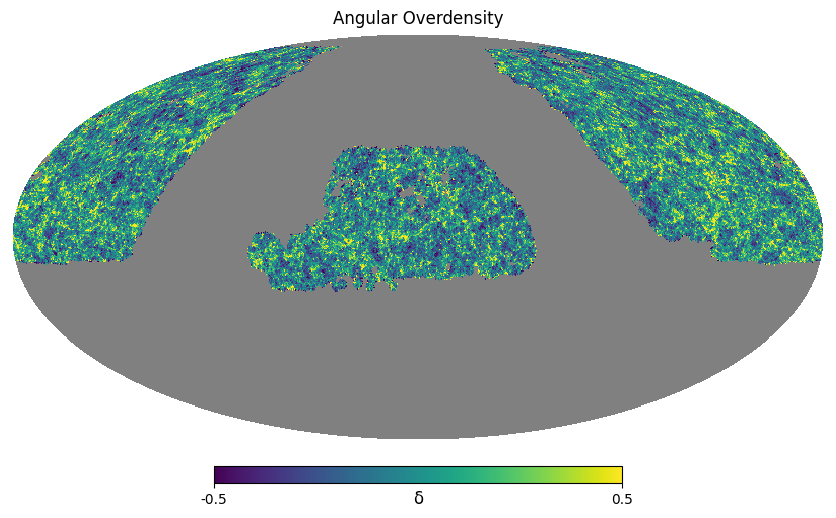

In [81]:
hp.mollview(delta_ang, min=-0.5, max=0.5, title="Angular Overdensity", unit="δ")
plt.show()

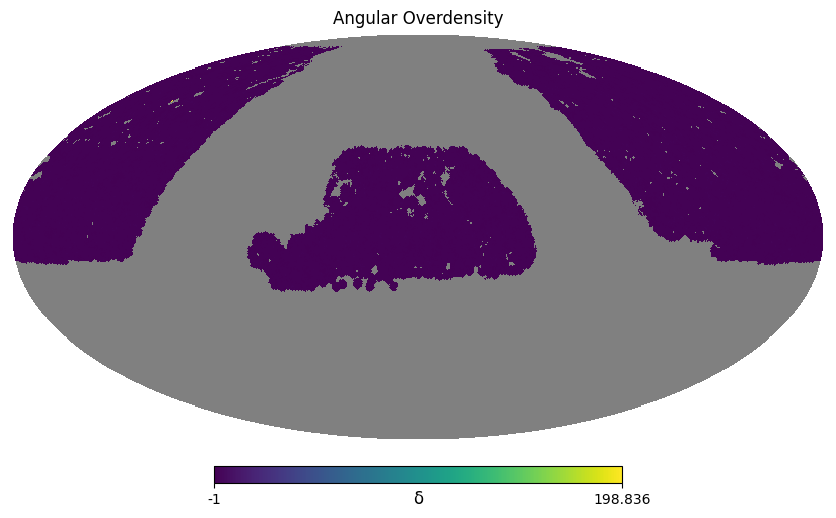

In [19]:
hp.mollview(delta_ang, title="Angular Overdensity", unit="δ")
plt.show()

In [20]:
@njit
def cic_deposit_weighted_numba(rho, x, y, z, w, xmin, ymin, zmin, dx, dy, dz):
    N = rho.shape[0]
    for p in range(x.shape[0]):
        gx = (x[p] - xmin) / dx
        gy = (y[p] - ymin) / dy
        gz = (z[p] - zmin) / dz

        i = int(np.floor(gx))
        j = int(np.floor(gy))
        k = int(np.floor(gz))

        wx = gx - i
        wy = gy - j
        wz = gz - k

        # 8 neighboring cells
        for di in (0, 1):
            ii = i + di
            if ii < 0 or ii >= N:
                continue
            fx = (1.0 - wx) if di == 0 else wx

            for dj in (0, 1):
                jj = j + dj
                if jj < 0 or jj >= N:
                    continue
                fy = (1.0 - wy) if dj == 0 else wy

                for dk in (0, 1):
                    kk = k + dk
                    if kk < 0 or kk >= N:
                        continue
                    fz = (1.0 - wz) if dk == 0 else wz

                    rho[ii, jj, kk] += w[p] * fx * fy * fz

In [21]:
L = 2000.0 # cubic box of side lenth L
N = 192 # discretized into N^3 voxels
dx = L / N # each voxel has size dxb
print(f"Each voxel has size: {dx} Mpc")

Each voxel has size: 10.416666666666666 Mpc


In [22]:
# convert (RA, DEC, Z) to comoving (x,y,z)
def comoving_xyz(ra_deg, dec_deg, z):
    chi = cosmo.comoving_distance(z).to_value(u.Mpc)
    ra  = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)
    x = chi*np.cos(dec)*np.cos(ra)
    y = chi*np.cos(dec)*np.sin(ra)
    zc = chi*np.sin(dec)
    return x, y, zc

In [23]:
#redshift cut for gals
m = (arr_d["Z"] > 0.02) & (arr_d["Z"] < 0.25) & np.isfinite(arr_d["Z"])
print("Number of galaxies in z-range:", len(arr_d[m]))

xg, yg, zg = comoving_xyz(arr_d["RA"][m], arr_d["DEC"][m], arr_d["Z"][m].astype(float)) # now each galaxy has a 3D caresian position in comoving cords.
xc, yc, zc = np.mean(xg), np.mean(yg), np.mean(zg) # compute the center of the galaxy distribution so later we can define the cubic grid around it

wg = arr_d["WEIGHT"][m].astype(np.float32) # select gal weights for the same redshift cut galaxies
wg_sum = float(wg.sum()) # total weighted number of gals in redshift cut (to be used for alpha normalization)

# define cube bounds (side lenth L, centered on (xc, yc, zc)
xmin = xc - L/2; xmax = xc + L/2
ymin = yc - L/2; ymax = yc + L/2
zmin = zc - L/2; zmax = zc + L/2

# compute voxel size (to double check code is working as expected)
dx = (xmax-xmin)/N
dy = (ymax-ymin)/N
dz = (zmax-zmin)/N
print(f"Voxel sizes: {dx, dy, dz}")

Number of galaxies in z-range: 6388331
Voxel sizes: (10.416666666666666, 10.416666666666666, 10.416666666666666)


In [24]:
rho_r = np.zeros((N, N, N), dtype=np.float32)

for fn in tqdm(ran_files, desc="Gridding randoms"):
    arr_r = fitsio.read(fn, columns=["RA","DEC","Z"], ext=1)

    mr = (arr_r["Z"] > 0.02) & (arr_r["Z"] < 0.25) & np.isfinite(arr_r["Z"])

    xr, yr, zr = comoving_xyz(
        arr_r["RA"][mr],
        arr_r["DEC"][mr],
        arr_r["Z"][mr].astype(float)
    )

    wr = np.ones(xr.size, dtype=np.float32)

    inside = (xr>=xmin)&(xr<xmin+L)&(yr>=ymin)&(yr<ymin+L)&(zr>=zmin)&(zr<zmin+L)
    xr, yr, zr, wr = xr[inside], yr[inside], zr[inside], wr[inside]

    cic_deposit_weighted_numba(rho_r, xr, yr, zr, wr,
                               xmin, ymin, zmin,
                               dx, dy, dz)

print("rho_r.sum():", float(rho_r.sum()))

Gridding randoms:   0%|          | 0/18 [00:00<?, ?it/s]

rho_r.sum(): 301402752.0


In [25]:
# verify cube contains galaxies of interest
inside = (
    (xg >= xmin) & (xg < xmax) &
    (yg >= ymin) & (yg < ymax) &
    (zg >= zmin) & (zg < zmax)
)

print("Fraction of galaxies inside cube:", inside.mean())

# Are exclusions mostly near the boundary? (distance to nearest face)
dist_to_face = np.minimum.reduce([
    xg - xmin, xmax - xg,
    yg - ymin, ymax - yg,
    zg - zmin, zmax - zg
])
print("median dist to face (inside):", float(np.median(dist_to_face[inside])))
print("median dist to face (outside):", float(np.median(dist_to_face[~inside])))

Fraction of galaxies inside cube: 0.9773989481759789
median dist to face (inside): 487.99356702146224
median dist to face (outside): -47.82183092133505


In [26]:
# verify cube contains randoms
inside_r = (xr>=xmin)&(xr<xmax)&(yr>=ymin)&(yr<ymax)&(zr>=zmin)&(zr<zmax)
print("Fraction of randoms inside cube:", inside_r.mean()) # want to be 100% since we computed rho_r inside volume

Fraction of randoms inside cube: 1.0


In [27]:
rho_g = np.zeros((N,N,N), dtype=np.float32)
cic_deposit_weighted_numba(rho_g, xg, yg, zg, wg, xmin,ymin,zmin, dx,dy,dz)
print("rho_g sum:", float(rho_g.sum()))

rho_g sum: 9325441.0


In [28]:
# Should see random total > than galaxy total because randoms are denser
print("Total galaxy weight:", wg_sum)
print("Total random count:", rho_r.sum())

Total galaxy weight: 9561825.0
Total random count: 301402750.0


In [29]:
# want the expected mean from randoms to match the total weighted galaxies within the region analyzed, so choose alpha so that the sum of rho_g equals alpha times the sum of rho_r
# We don't want to to use rho_g or rho_r yet, these totals include many edge voxels and can be biased towards low coverage regions
# define a mask from randoms
thr = 0.01 * np.mean(rho_r[rho_r > 0])
mask_thr = rho_r > thr
print("Percent of masked cube volume inside the survey footprint:", float(mask_thr.mean()))
print("rho_r mean in mask:", float(rho_r[mask_thr].mean())) # avg voxel contains this many randoms

edge_survey = mask_thr.mean() / mask.mean()
print("Fraction of footprint volume that survives the stricter threshold cut:", edge_survey)

Percent of masked cube volume inside the survey footprint: 0.2098905775282118
rho_r mean in mask: 202.86997985839844
Fraction of footprint volume that survives the stricter threshold cut: 0.6004010805410466


In [30]:
# compute alpha
alpha = rho_g[mask_thr].sum() / rho_r[mask_thr].sum()
print("alpha:", float(alpha), "1/alpha:", float(1/alpha))

alpha: 0.0309400986880064 1/alpha: 32.32051746453024


In [31]:
# create density cube for classification
density_cube = np.ones_like(rho_g, dtype=np.float32) # initialize the cube
density_cube[mask_thr] = rho_g[mask_thr] / (alpha * rho_r[mask_thr]) # for voxels inside "well-sampled region" compute the 1 + delta density

print("mean(1+δ) in mask:", float(density_cube[mask_thr].mean())) # should be close to one inside the mask
print("std(1+δ) in mask:", float(density_cube[mask_thr].std()))
print("min/max(1+δ) in mask:", float(density_cube[mask_thr].min()), float(density_cube[mask_thr].max()))

mean(1+δ) in mask: 1.000980257987976
std(1+δ) in mask: 1.2958128452301025
min/max(1+δ) in mask: 0.0 45.409698486328125


In [32]:
mx = density_cube[mask_thr].max()
loc = np.unravel_index(np.argmax(density_cube * mask_thr), density_cube.shape)
print("max 1+δ:", mx, "at index", loc)
print("rho_g there:", float(rho_g[loc]))
print("rho_r there:", float(rho_r[loc]))
print("alpha*rho_r there:", float(alpha * rho_r[loc]))

max 1+δ: 45.4097 at index (146, 111, 62)
rho_g there: 30.165952682495117
rho_r there: 21.470726013183594
alpha*rho_r there: 0.6643064022064209


In [33]:
print("fraction (1+δ > 50):", float((density_cube[mask_thr] > 50).mean()))
print("fraction (1+δ > 100):", float((density_cube[mask_thr] > 100).mean()))

fraction (1+δ > 50): 0.0
fraction (1+δ > 100): 0.0


In [34]:
Rs_vox = [1, 2, 3, 4, 6, 8, 12] # NEXUSPLUS wants a range of smoothing scales
Rs_Mpc = [rv * dx for rv in Rs_vox]
print("dx:", dx)
print("Rs_vox:", Rs_vox)
print("Rs_Mpc:", Rs_Mpc)

dx: 10.416666666666666
Rs_vox: [1, 2, 3, 4, 6, 8, 12]
Rs_Mpc: [10.416666666666666, 20.833333333333332, 31.25, 41.666666666666664, 62.5, 83.33333333333333, 125.0]


In [35]:
max_sigs = mmf.maximum_signature(Rs_vox, density_cube, algorithm="NEXUSPLUS")
clus, fil, wall, void = mmf.calc_structure_bools(density_cube, max_sigs, verbose_flag=False)

print("Volume fractions (mask only):",
      "cluster", float(clus[mask_thr].mean()), # 0 percent since clusters are contained within one voxel, not enough to detect them clusters (1-10Mpc across)
      "filament", float(fil[mask_thr].mean()),
      "wall", float(wall[mask_thr].mean()),
      "void", float(void[mask_thr].mean()))

/global/homes/j/jlargett/miniforge3/lib/python3.10/site-packages/pycosmommf/tagging.py:68: RuntimeWarning: invalid value encountered in scalar divide
  virialized_fractions[i] = np.sum(


Volume fractions (mask only): cluster 0.0 filament 0.5163255882206434 wall 0.029169712610949784 void 0.45450469916840675


In [36]:
# Let's find clusters
Vizier.ROW_LIMIT = -1  # get all rows

# This catalog is hosted at VizieR as J/ApJS/272/39
# The main table file listed by CDS is table2
cats = Vizier.get_catalogs("J/ApJS/272/39") # fetch the cluster table
print("Number of tables returned:", len(cats))
for i, t in enumerate(cats):
    print(i, t.meta.get("name", "no-name"), "nrows=", len(t)) # print the column names so we can pull RA/DEC/z fields

cl = cats[0]  # usually the main cluster table
print("Columns:", cl.colnames)

Number of tables returned: 1
0 J/ApJS/272/39/table2 nrows= 1581179
Columns: ['ID', 'n_Name', 'Name', 'RAJ2000', 'DEJ2000', 'zCl', 'f_zCl', 'zmag', 'W1mag', 'logMs', 'r500', 'lam500', 'M500', 'Ngal', 'Gamma', 'e_Gamma', 'imag?', 'Cat']


In [37]:
ra_wen  = np.array(cl["RAJ2000"], dtype=float)
dec_wen = np.array(cl["DEJ2000"], dtype=float)
z_wen   = np.array(cl["zCl"], dtype=float)

# cut to BGS z-range
z_cut = (z_wen > 0.02) & (z_wen < 0.25) & np.isfinite(z_wen)

ra_wen, dec_wen, z_wen = ra_wen[z_cut], dec_wen[z_cut], z_wen[z_cut]
print("clusters in z-range:", ra_wen.size)

# comoving xyz (Mpc) using your existing function
xc_wen, yc_wen, zc_wen = comoving_xyz(ra_wen, dec_wen, z_wen)

clusters in z-range: 101740


In [38]:
# convert xyz to voxel indicies and build clus_ext using existing cube
clus_ext = np.zeros((N, N, N), dtype=bool) # init clus_ext

i = np.floor((xc_wen - xmin)/dx).astype(np.int64)
j = np.floor((yc_wen - ymin)/dy).astype(np.int64)
k = np.floor((zc_wen - zmin)/dz).astype(np.int64)

inside = (i >= 0) & (i < N) & (j >= 0) & (j < N) & (k >= 0) & (k < N)
i, j, k = i[inside], j[inside], k[inside]

clus_ext[i, j, k] = True # classify a cluster as a voxel that contains the cataloged cluster center from Wen (https://arxiv.org/abs/2404.02002)
print("clus_ext voxels set:", int(clus_ext.sum()))
print("clus_ext voxels in mask_thr:", int((clus_ext & mask_thr).sum()))

clus_ext voxels set: 87296
clus_ext voxels in mask_thr: 55009


In [39]:
clus, fil, wall, void = mmf.calc_structure_bools(
    density_cube, max_sigs,
    clusbool=clus_ext,
    verbose_flag=False
)

print("Volume fractions (mask only):",
      "cluster", float(clus[mask_thr].mean()), # voxels that contain a cataloged cluster center on a dx = 10.4 Mpc grida
      "filament", float(fil[mask_thr].mean()),
      "wall", float(wall[mask_thr].mean()),
      "void", float(void[mask_thr].mean()))

Volume fractions (mask only): cluster 0.03702858542981808 filament 0.4897016792072063 wall 0.027814014978641367 void 0.44545572038433423


In [40]:
frac_clus = clus[mask_thr].mean()
frac_fil = fil[mask_thr].mean()
frac_wall = wall[mask_thr].mean()
frac_void = void[mask_thr].mean()

fractions = np.array([frac_clus, frac_fil, frac_wall, frac_void])
labels = ["Cluster", "Filament", "Wall", "Void"]

print("Fractions:", dict(zip(labels, fractions)))
print("Sum:", fractions.sum()) # sum should be 1

Fractions: {'Cluster': 0.03702858542981808, 'Filament': 0.4897016792072063, 'Wall': 0.027814014978641367, 'Void': 0.44545572038433423}
Sum: 1.0


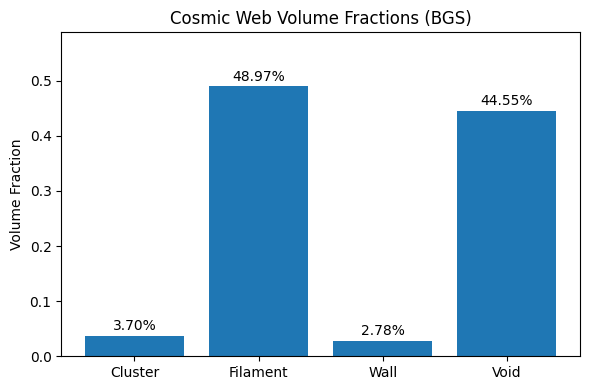

In [41]:
# create histogram
plt.figure(figsize=(6,4))
bars = plt.bar(labels, fractions)

for bar, frac in zip(bars, fractions):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f"{100*frac:.2f}%",
             ha='center')

plt.ylabel("Volume Fraction")
plt.title("Cosmic Web Volume Fractions (BGS)")
plt.ylim(0, max(fractions)*1.2)
plt.tight_layout()
plt.show()

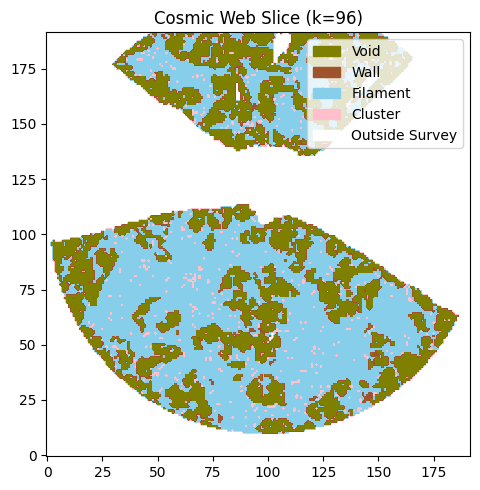

In [42]:
k = density_cube.shape[2] // 2  # slice on z-axis

# Make a label image: 0 void, 1 wall, 2 filament, 3 cluster, 4 outside threshold
labels = np.full(density_cube.shape, 4, dtype=np.uint8)
labels[mask_thr & void] = 0
labels[mask_thr & wall] = 1
labels[mask_thr & fil] = 2
labels[mask_thr & clus] = 3

# Define custom colors
cmap = ListedColormap([
    "olive",     # 0 void
    "sienna",    # 1 wall
    "skyblue",       # 2 filament
    "pink",      # 3 cluster
    "white"      # 4 outside mask
])

plt.figure(figsize=(6,5))
plt.imshow(labels[:, :, k], origin="lower", cmap=cmap, vmin=0, vmax=4)
plt.title(f"Cosmic Web Slice (k={k})")

legend_elements = [
    mpatches.Patch(color="olive", label="Void"),
    mpatches.Patch(color="sienna", label="Wall"),
    mpatches.Patch(color="skyblue", label="Filament"),
    mpatches.Patch(color="pink", label="Cluster"),
    mpatches.Patch(color="white", label="Outside Survey"),
]

plt.legend(handles=legend_elements, loc="upper right")
plt.tight_layout()
plt.show()

In [43]:
# make slice plot gif
Nz = labels.shape[2]

fig, ax = plt.subplots(figsize=(6,5))

# Define colormap
cmap = ListedColormap([
    "olive",     # void
    "sienna",    # wall
    "skyblue",   # filament
    "pink",      # cluster
    "white"      # outside
])

# Initial image
im = ax.imshow(labels[:, :, 0], origin="lower", cmap=cmap, vmin=0, vmax=4)
title = ax.set_title("Cosmic Web Slice k=0")

# Legend (only add once)
legend_elements = [
    mpatches.Patch(color="olive", label="Void"),
    mpatches.Patch(color="sienna", label="Wall"),
    mpatches.Patch(color="skyblue", label="Filament"),
    mpatches.Patch(color="pink", label="Cluster"),
    mpatches.Patch(color="white", label="Outside Survey"),
]
ax.legend(handles=legend_elements, loc="upper right")

def update(frame):
    im.set_data(labels[:, :, frame])
    title.set_text(f"Cosmic Web Slice k={frame}")
    return im, title

anim = FuncAnimation(fig, update, frames=Nz, interval=100)

# Save as GIF
#anim.save("cosmic_web_slices.gif", writer=PillowWriter(fps=10))

plt.close(fig)
#print("Saved cosmic_web_slices.gif")

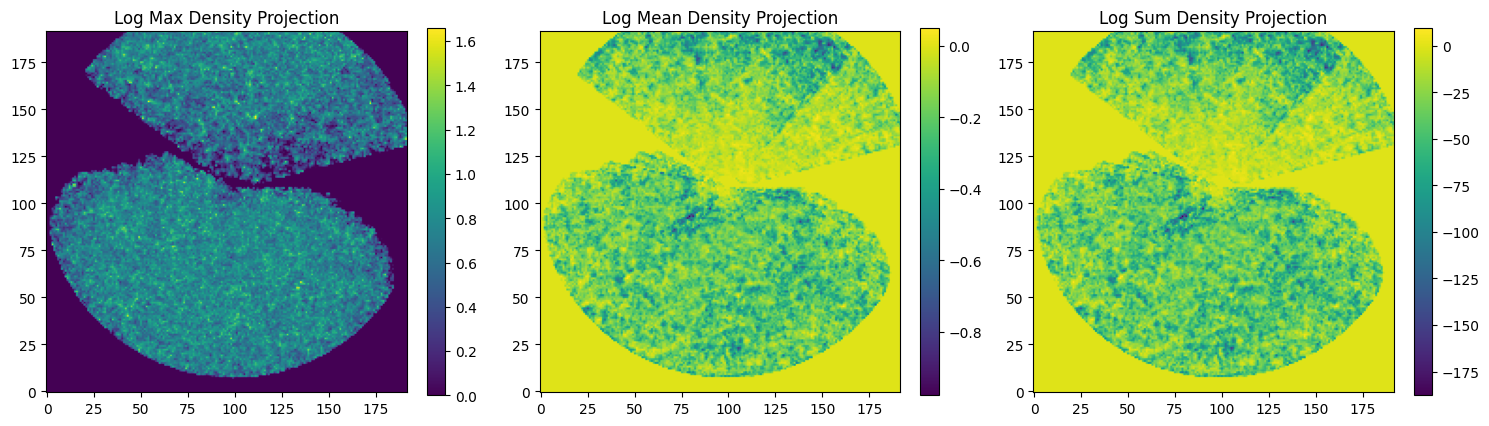

In [44]:
# Avoid log10(0) issues
eps = 1e-10
log_field = np.log10(density_cube + eps)

# Projections along z-axis
proj_max  = log_field.max(axis=2)
proj_mean = log_field.mean(axis=2)
proj_sum  = log_field.sum(axis=2)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

im0 = ax[0].imshow(proj_max, origin="lower")
ax[0].set_title("Log Max Density Projection")
plt.colorbar(im0, ax=ax[0], fraction=0.046)

im1 = ax[1].imshow(proj_mean, origin="lower")
ax[1].set_title("Log Mean Density Projection")
plt.colorbar(im1, ax=ax[1], fraction=0.046)

im2 = ax[2].imshow(proj_sum, origin="lower")
ax[2].set_title("Log Sum Density Projection")
plt.colorbar(im2, ax=ax[2], fraction=0.046)

plt.tight_layout()
plt.show()

Void surface voxels: 425036
Wall surface voxels: 41295
Filament surface voxels: 404183
Cluster surface voxels: 55007


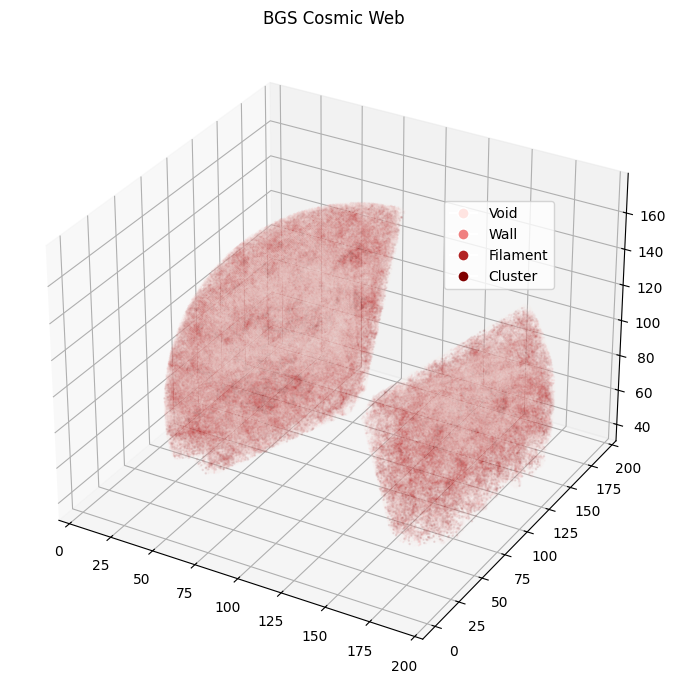

In [45]:
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Void',
           markerfacecolor='mistyrose', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Wall',
           markerfacecolor='lightcoral', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Filament',
           markerfacecolor='firebrick', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Cluster',
           markerfacecolor='maroon', markersize=8),
]

# Surface extractor
def surface_coords(mask3d):
    surf = mask3d & ~binary_erosion(mask3d)
    return np.argwhere(surf)

# Apply mask_thr restriction
clus_show = clus & mask_thr
fil_show  = fil  & mask_thr
wall_show = wall & mask_thr
void_show = void & mask_thr

# Get all surface coordinates (no subsampling)
coords_void = surface_coords(void_show)
coords_wall = surface_coords(wall_show)
coords_fil  = surface_coords(fil_show)
coords_clus = surface_coords(clus_show)

print("Void surface voxels:", coords_void.shape[0])
print("Wall surface voxels:", coords_wall.shape[0])
print("Filament surface voxels:", coords_fil.shape[0])
print("Cluster surface voxels:", coords_clus.shape[0])

fig = plt.figure(figsize=(8,7))
ax = fig.add_subplot(111, projection="3d")

# Plot each structure with chosen colors
ax.scatter(coords_void[:,0], coords_void[:,1], coords_void[:,2],
           s=0.5, alpha=0.03, color="mistyrose", label="Void")

ax.scatter(coords_wall[:,0], coords_wall[:,1], coords_wall[:,2],
           s=0.5, alpha=0.09, color="lightcoral", label="Wall")

ax.scatter(coords_fil[:,0], coords_fil[:,1], coords_fil[:,2],
           s=0.5, alpha=0.03, color="firebrick", label="Filament")

ax.scatter(coords_clus[:,0], coords_clus[:,1], coords_clus[:,2],
           s=0.8, alpha=0.09, color="maroon", label="Cluster")

ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.85, 0.75))
ax.set_title("BGS Cosmic Web")

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_zlabel("")

# Make background transparent
fig.patch.set_alpha(0)
ax.set_facecolor((1,1,1,0))

# Save figure with transparency
#plt.savefig("cosmic_web.png", dpi=300, transparent=True, bbox_inches="tight", pad_inches=0)
    
plt.tight_layout()
plt.show()

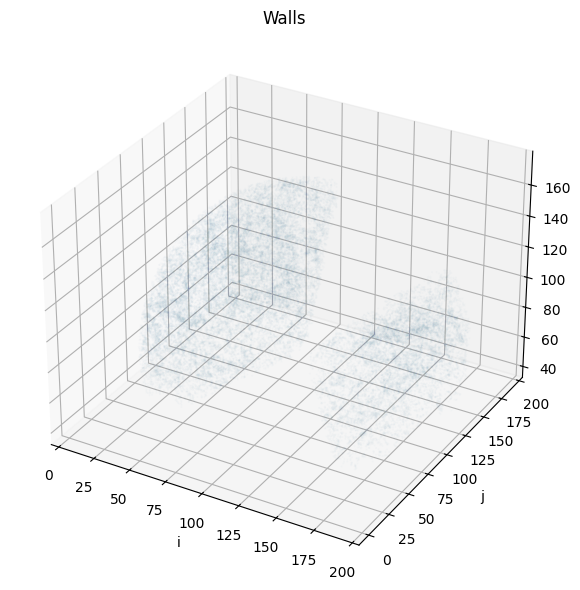

In [46]:
show = wall & mask_thr
surface = show & ~binary_erosion(show)
coords = np.argwhere(surface)

x, y, z = coords[:,0], coords[:,1], coords[:,2]

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x, y, z, s=0.5, alpha=0.01)

ax.set_title("Walls")
ax.set_xlabel("i")
ax.set_ylabel("j")
ax.set_zlabel("k")

plt.tight_layout()
plt.show()

In [47]:
bgs = Table.read('/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP/BGS_ANY_clustering.dat.fits')

In [48]:
bgs

TARGETID,TILEID,Z,NTILE,RA,DEC,PHOTSYS,FRAC_TLOBS_TILES,WEIGHT_ZFAIL,BITWEIGHTS,PROB_OBS,WEIGHT,WEIGHT_COMP,WEIGHT_SYS,flux_g_dered,flux_r_dered,flux_z_dered,flux_w1_dered,flux_w2_dered
int64,int64,float64,int64,float64,float64,bytes1,float64,float64,int64[2],float64,float64,float64,float64,float32,float32,float32,float32,float32
39627322533347488,23286,0.39335480800366573,1,11.120287113169812,-19.38303726854656,S,0.9796300924768808,1.0000042915344238,-1 .. -1,1.0,1.0000042915344238,1.0,1.0,6.308694,14.59653,26.823706,37.508904,34.790462
39627322533349236,23286,0.43184135505202836,1,11.169501569086401,-19.3861795902248,S,0.9796300924768808,1.000115990638733,-1 .. -1,1.0,1.000115990638733,1.0,1.0,4.1814938,11.420789,21.353018,30.502308,34.404987
39627322533350395,23286,0.2740917674284791,1,11.20171365459861,-19.375325006211153,S,0.9796300924768808,1.0,8239573393633327117 .. -3031389160879646369,0.5,3.0,3.0,1.0,8.085996,30.673317,63.10016,68.74799,48.995106
39627322701120343,20169,0.03473854076532627,1,21.726569006764297,-19.404267970287048,S,0.9856640166818715,1.000009298324585,-1 .. -1,1.0,1.000009298324585,1.0,1.0,33.10879,42.421165,49.190315,27.26047,18.614767
39627322701120643,20169,0.25221186231954623,1,21.73359607258574,-19.375605113382576,S,0.9856640166818715,1.0,-1 .. -1,1.0,1.0,1.0,1.0,20.810436,73.10186,149.16689,135.6446,99.00061
39627322701122007,20169,0.27217764349707185,1,21.768264092806554,-19.389506028657603,S,0.9856640166818715,1.000050663948059,-288265560658546754 .. -1152958922899981313,0.8828125,2.000101327896118,2.0,1.0,10.946467,20.158052,29.95784,25.99714,28.728113
39627322701123557,20169,0.3763212132049159,1,21.814574461490338,-19.385004666704173,S,0.9856640166818715,1.0,-1 .. -1,1.0,1.0,1.0,1.0,5.455156,26.550306,58.063454,92.51501,56.048416
39627322701123768,20169,0.25308210632931394,1,21.821399980015304,-19.41746023599328,S,0.9856640166818715,1.0,-4612491008829702721 .. 6818129726859256825,0.625,3.0,3.0,1.0,18.194235,61.44949,115.34717,124.56431,86.61836
39627322701124950,20169,0.21127816101664984,1,21.853334546048778,-19.416994357433538,S,0.9856640166818715,1.0,-5892114244089902865 .. 1743694035413370744,0.40625,4.0,4.0,1.0,12.755774,38.84009,74.58444,71.4307,50.762054


In [49]:
# classify all BGS catalog rows (within z-cut + cube + mask_thr) into web types
zcol = "Z"

# cuts: same z-range as cube build
m_bgs = (bgs[zcol] > 0.02) & (bgs[zcol] < 0.25) & np.isfinite(bgs[zcol])

# comoving xyz for these rows
xb, yb, zb = comoving_xyz(bgs["RA"][m_bgs], bgs["DEC"][m_bgs], bgs[zcol][m_bgs].astype(float))

# inside cube bounds (same as earlier)
inside_cube = (
    (xb >= xmin) & (xb < xmax) &
    (yb >= ymin) & (yb < ymax) &
    (zb >= zmin) & (zb < zmax)
)

# voxel indices
ib = np.floor((xb - xmin)/dx).astype(np.int64)
jb = np.floor((yb - ymin)/dy).astype(np.int64)
kb = np.floor((zb - zmin)/dz).astype(np.int64)

# inside the trusted threshold (mask_thr)
inside_mask = np.zeros(len(xb), dtype=bool)
inside_mask[inside_cube] = mask_thr[ib[inside_cube], jb[inside_cube], kb[inside_cube]]

# get gals inside zcut + cube + mask_thr
eligible = inside_cube & inside_mask

In [50]:
# Read off MMF masks at galaxy voxels
gclus = np.zeros(len(xb), dtype=bool)
gfil  = np.zeros(len(xb), dtype=bool)
gwall = np.zeros(len(xb), dtype=bool)
gvoid = np.zeros(len(xb), dtype=bool)

gclus[eligible] = clus[ib[eligible], jb[eligible], kb[eligible]]
gfil[eligible]  = fil [ib[eligible], jb[eligible], kb[eligible]]
gwall[eligible] = wall[ib[eligible], jb[eligible], kb[eligible]]
gvoid[eligible] = void[ib[eligible], jb[eligible], kb[eligible]]

# no voxel overlap, this should be <=1 always
mask_sum_g = gclus.astype(int)+gfil.astype(int)+gwall.astype(int)+gvoid.astype(int)
print("Max labels per eligible galaxy:", mask_sum_g[eligible].max())

Max labels per eligible galaxy: 1


In [51]:
# Build a single label for the zcut subset
web_sub = np.full(len(xb), "not_eligible", dtype=object) # initialize
web_sub[inside_cube & ~inside_mask] = "outside_mask" # low random coverage
web_sub[~inside_cube] = "outside_cube" # lies outside 2000Mpc cube
web_sub[eligible] = "unclassified"   # voxel wasn't classified as clus/fil/wall/void

web_sub[eligible & gvoid] = "void"
web_sub[eligible & gwall] = "wall"
web_sub[eligible & gfil]  = "filament"
web_sub[eligible & gclus] = "cluster"

# Attach to full bgs table (same length as bgs)
bgs["web_type"] = np.full(len(bgs), "no_web", dtype=object)  # fails z-cut or missing z
bgs["web_type"][m_bgs] = web_sub

In [52]:
len(bgs["web_type"])

11504552

In [53]:
# print labels
counts = Counter(bgs["web_type"])
for k in ["no_web",
          "outside_cube",
          "outside_mask",
          "unclassified",
          "cluster",
          "filament",
          "wall",
          "void"]:
    if k in counts:
        print(f"{k:12s}: {counts[k]}")

no_web      : 5116221
outside_cube: 144383
outside_mask: 2007
cluster     : 824741
filament    : 3983067
wall        : 179599
void        : 1254534


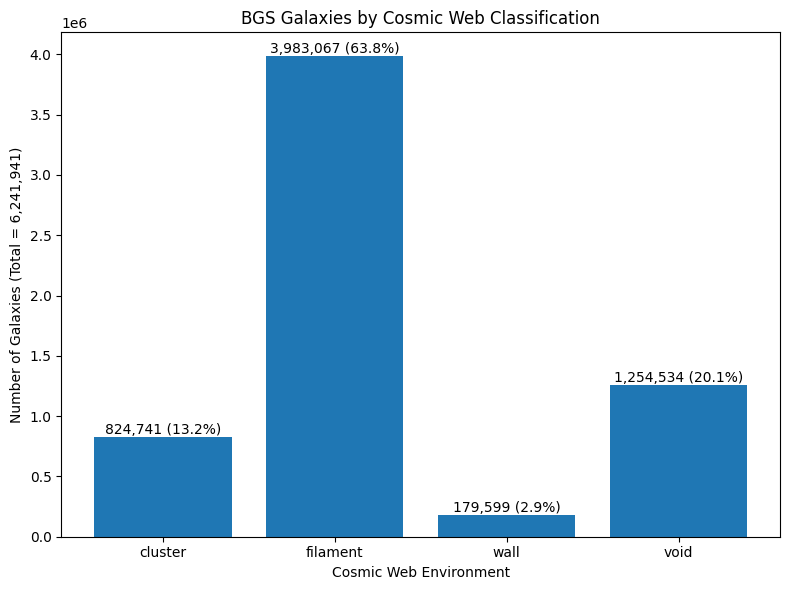

In [54]:
# make bar graph
counts = Counter(bgs["web_type"])

web_classes = ["cluster", "filament", "wall", "void"]
values = np.array([counts.get(w, 0) for w in web_classes])

total_classified = values.sum()
fractions = values / total_classified

total_classified = sum(values)
plt.figure(figsize=(8,6))
bars = plt.bar(web_classes, values)

# Add count + percentage above each bar
for bar, v, frac in zip(bars, values, fractions):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{v:,} ({frac*100:.1f}%)",
        ha='center',
        va='bottom'
    )

plt.ylabel(f"Number of Galaxies (Total = {total_classified:,})")
plt.xlabel("Cosmic Web Environment")
plt.title("BGS Galaxies by Cosmic Web Classification")

plt.tight_layout()
plt.show()

In [55]:
print("Total classified:", total_classified)
print("Fraction of full BGS classified:",
      total_classified / len(bgs))

Total classified: 6241941
Fraction of full BGS classified: 0.5425627177833608


In [56]:
sga2020 = Table.read('/pscratch/sd/j/jlargett/DESI_SGA_MINE/Morp_Density_Relation/sga_id_class_ra_dec.fits', hdu=1)
sga2020

SGA_ID,Classification,RA,DEC
float64,bytes12,float64,float64
2.0,Spiral,228.3770803831908,5.423191398593787
3.0,Spiral,202.5444619671207,6.9346244322326624
4.0,Irregular,222.7497050504303,13.861929561160224
7.0,Spiral,182.08882232629614,25.60226821438983
18.0,Elliptical,188.53364923054596,45.595620212931856
20.0,Irregular,263.55294849855886,57.344862145664294
24.0,Elliptical,247.42445048371366,40.24820033835744
25.0,Irregular,227.47031353123606,13.256402782093659
26.0,Elliptical,163.5984039051307,54.41298240323229


In [57]:
# pick the right column names for your tables
bgs_ra, bgs_dec = bgs["RA"], bgs["DEC"]
sga_ra, sga_dec = sga2020["RA"], sga2020["DEC"]

c_bgs = SkyCoord(ra=bgs_ra*u.deg, dec=bgs_dec*u.deg)
c_sga = SkyCoord(ra=sga_ra*u.deg, dec=sga_dec*u.deg)

idx_bgs, sep2d, _ = c_sga.match_to_catalog_sky(c_bgs)

In [58]:
match_radius = 1.0 * u.arcsec
ok = sep2d < match_radius

print("Matched:", ok.sum(), "/", len(sga2020))
print("Median sep (arcsec):", np.median(sep2d[ok].to_value(u.arcsec)))

Matched: 177555 / 383618
Median sep (arcsec): 0.0


In [59]:
sga_m = sga2020[ok]
bgs_m = bgs[idx_bgs[ok]]

morph = np.array(sga_m["Classification"])
web   = np.array(bgs_m["web_type"])

print("Matched within 1 arcsec:", len(sga_m))
print("Matched & eligible web:", np.sum(np.isin(web, ["cluster","filament","wall","void"])))

Matched within 1 arcsec: 177555
Matched & eligible web: 167152


In [60]:
# keep only those with a real web class
good = np.isin(web, ["cluster","filament","wall","void"])

sga_good = sga_m[good]
bgs_good = bgs_m[good]

In [61]:
# extract morph and web
morph = np.array(sga_good["Classification"])
web   = np.array(bgs_good["web_type"])

print("Number of matched classified galaxies:", len(morph))
print("Number of bgs galaxies:", len(web))

Number of matched classified galaxies: 167152
Number of bgs galaxies: 167152


In [62]:
morph_types = np.unique(morph)
web_types   = ["cluster", "filament", "wall", "void"]

counts_2d = np.zeros((len(morph_types), len(web_types)), dtype=int)

for i, mt in enumerate(morph_types):
    for j, wt in enumerate(web_types):
        counts_2d[i, j] = np.sum((morph == mt) & (web == wt))

print("Rows (morph):", morph_types)
print("Columns (web):", web_types)
print(counts_2d)

Rows (morph): [b'Elliptical' b'Irregular' b'Lenticular' b'Spiral' b'Unclassified']
Columns (web): ['cluster', 'filament', 'wall', 'void']
[[ 7951 28297   843  5840]
 [ 3139 16786   668  5476]
 [ 3109 12471   501  3539]
 [ 8846 51002  1825 14761]
 [  356  1358    50   334]]


In [63]:
# morphology + web arrays
morph_raw = np.array(sga_good["Classification"])
web = np.array(bgs_good["web_type"], dtype=str)

# bytes to str, strip whitespace
if morph_raw.dtype.kind in ("S", "O"):
    morph = np.char.decode(morph_raw.astype("S"), "utf-8", errors="ignore")
else:
    morph = morph_raw.astype(str)

morph = np.char.strip(morph.astype(str))

# if any blanks remain, map to Unclassified
morph[morph == ""] = "Unclassified"

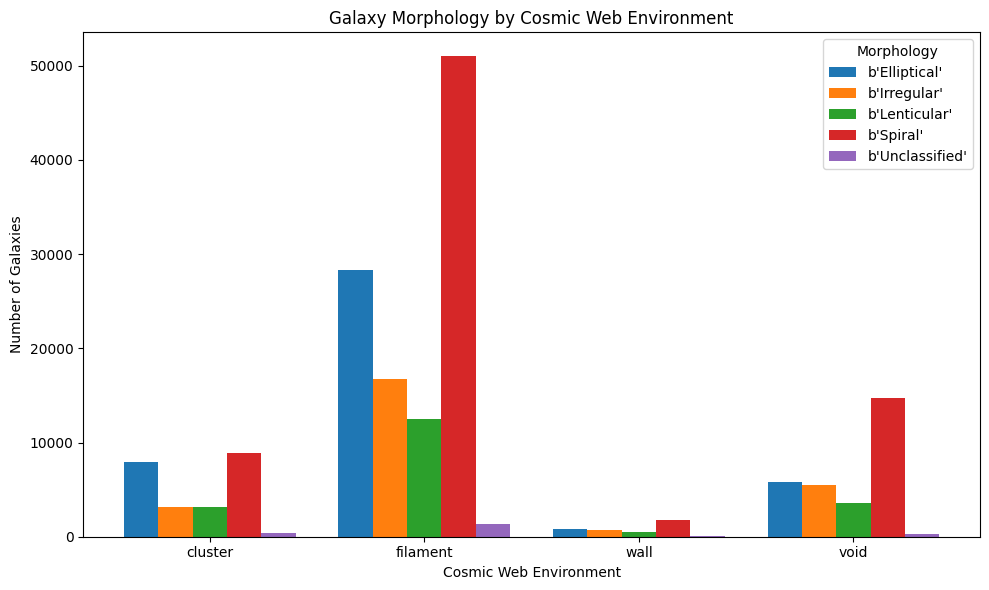

In [64]:
# grouped bar plot
x = np.arange(len(web_types))
width = 0.8 / len(morph_types)

plt.figure(figsize=(10,6))
for i, mt in enumerate(morph_types):
    plt.bar(x + i*width, counts_2d[i], width=width, label=str(mt))  # str(mt) is now safe

plt.xticks(x + width*(len(morph_types)-1)/2, web_types)
plt.ylabel("Number of Galaxies")
plt.xlabel("Cosmic Web Environment")
plt.title("Galaxy Morphology by Cosmic Web Environment")
plt.legend(title="Morphology", loc="upper right")
plt.tight_layout()
plt.show()

In [65]:
morph_order = ["Spiral", "Elliptical", "Lenticular", "Irregular", "Unclassified"]
morph_types = [m for m in morph_order if np.any(morph == m)]
extras = [m for m in np.unique(morph) if m not in morph_types]
morph_types += sorted(extras)

In [66]:
# Counts table and fractions
counts_2d = np.zeros((len(morph_types), len(web_types)), dtype=int)
for i, mt in enumerate(morph_types):
    for j, wt in enumerate(web_types):
        counts_2d[i, j] = np.sum((morph == mt) & (web == wt))

N_env = counts_2d.sum(axis=0)  # totals per environment
print("Totals per environment:", dict(zip(web_types, [int(n) for n in N_env])))

Totals per environment: {'cluster': 23401, 'filament': 109914, 'wall': 3887, 'void': 29950}


In [67]:
# compute standard error of a binomial proportion
fractions = np.zeros_like(counts_2d, dtype=float)
stderr = np.zeros_like(counts_2d, dtype=float)

for j in range(len(web_types)):
    n = N_env[j]
    if n == 0:
        continue
    fractions[:, j] = counts_2d[:, j] / n
    stderr[:, j] = np.sqrt(fractions[:, j] * (1.0 - fractions[:, j]) / n)

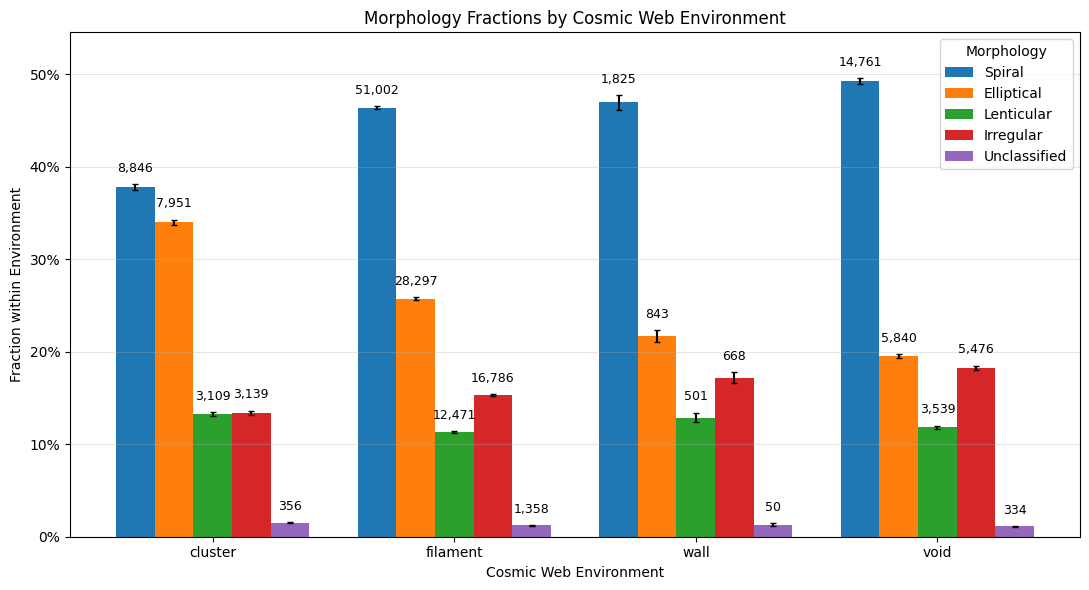

In [68]:
# Plot
x = np.arange(len(web_types))
width = 0.8 / len(morph_types)

plt.figure(figsize=(11, 6))
ax = plt.gca()

for i, mt in enumerate(morph_types):
    xpos = x + i * width
    y = fractions[i]
    yerr = stderr[i]

    bars = ax.bar(xpos, y, width=width, label=mt, yerr=yerr, capsize=2)

    # annotate per-bar counts k
    for j, bar in enumerate(bars):
        k = counts_2d[i, j]
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + yerr[j] + 0.01,
            f"{k:,}",
            ha="center", va="bottom", fontsize=9
        )

# center x tick labels on groups
group_centers = x + width * (len(morph_types) - 1) / 2
ax.set_xticks(group_centers)
ax.set_xticklabels(web_types)

ax.set_ylabel("Fraction within Environment")
ax.set_xlabel("Cosmic Web Environment")
ax.set_title("Morphology Fractions by Cosmic Web Environment")

# percent ticks + grid
yt = np.linspace(0, 1, 11)
ax.set_yticks(yt)
ax.set_yticklabels([f"{int(100*t)}%" for t in yt])
ax.grid(axis="y", alpha=0.3)

ax.set_ylim(0, np.max(fractions + stderr) * 1.1)
ax.legend(title="Morphology", loc="upper right")
plt.tight_layout()

fig = plt.gcf()   # get current figure

# Make the figure background transparent
fig.patch.set_alpha(0)

plt.show()

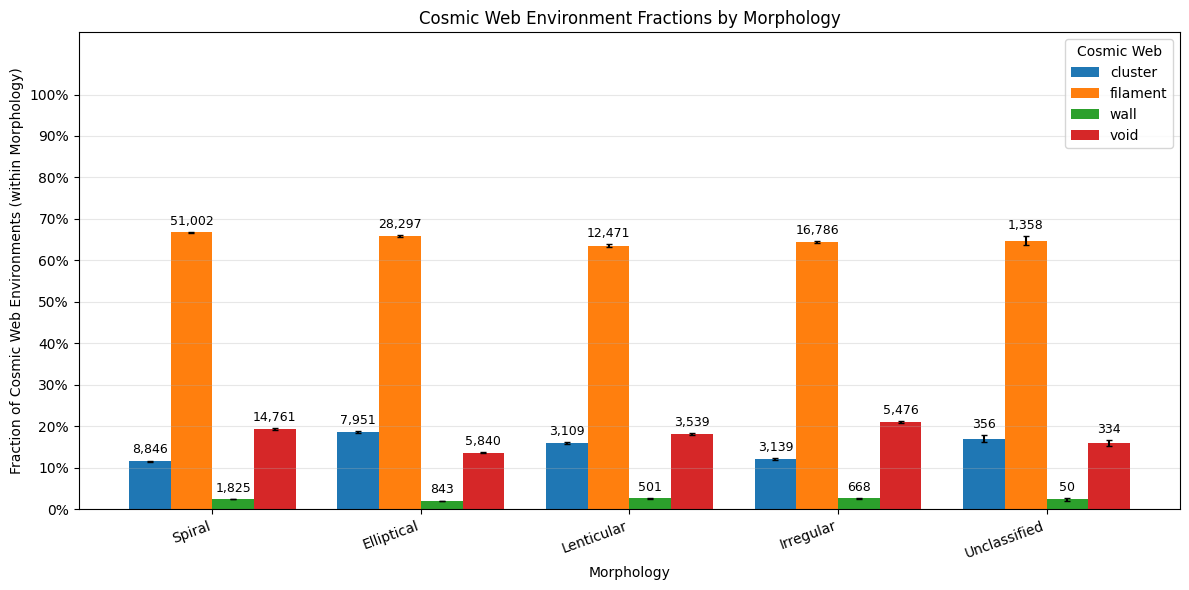

In [69]:
# counts_2d is shape (n_morph, n_web) with rows=morph, cols=web
# morph_types, web_types already defined

# totals per morphology (row sums)
N_morph = counts_2d.sum(axis=1)   # length = n_morph

# fractions: P(web | morph)
fractions_rev = np.zeros_like(counts_2d, dtype=float)
stderr_rev    = np.zeros_like(counts_2d, dtype=float)

for i in range(len(morph_types)):
    n = N_morph[i]
    if n == 0:
        continue
    fractions_rev[i, :] = counts_2d[i, :] / n
    stderr_rev[i, :] = np.sqrt(fractions_rev[i, :] * (1.0 - fractions_rev[i, :]) / n)

# Plot: groups are morphologies, bars are web environments
x = np.arange(len(morph_types))
width = 0.8 / len(web_types)

plt.figure(figsize=(12, 6))
ax = plt.gca()

for j, wt in enumerate(web_types):
    xpos = x + j * width
    y = fractions_rev[:, j]
    yerr = stderr_rev[:, j]

    bars = ax.bar(xpos, y, width=width, label=wt, yerr=yerr, capsize=2)

    # annotate counts above bars
    for i, bar in enumerate(bars):
        k = counts_2d[i, j]
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + yerr[i] + 0.01,
            f"{k:,}",
            ha="center", va="bottom", fontsize=9
        )

# center x tick labels on groups
group_centers = x + width * (len(web_types) - 1) / 2
ax.set_xticks(group_centers)
ax.set_xticklabels(morph_types, rotation=20, ha="right")

ax.set_ylabel("Fraction of Cosmic Web Environments (within Morphology)")
ax.set_xlabel("Morphology")
ax.set_title("Cosmic Web Environment Fractions by Morphology")

# percent ticks + grid
yt = np.linspace(0, 1, 11)
ax.set_yticks(yt)
ax.set_yticklabels([f"{int(100*t)}%" for t in yt])
ax.grid(axis="y", alpha=0.3)

ax.set_ylim(0, 1.15)
ax.legend(title="Cosmic Web", loc="upper right")
plt.tight_layout()
plt.show()